# ##Analysis Objectives

   Which restaurant is the best in profits?

   Which item is the best in profits?

   What are the avreage delivery times for orders?


  Understand customer behavior



  1.   What's the most common payment method used by customers?

  1.   What's the dish that customers order the most?
  2.   Which restaurant does the customer order from the most?






In [391]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/Food_Delivery.csv')
print('The dataset loaded successfully.')

The dataset loaded successfully.


In [392]:
df.head(5)

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
0,1,1102,Kebab House,alex,2024-01-01 00:00:00,40.0,Kebab,4,265,13,Wallet,1.0
1,2,1435,Sushi World,alex,2024-01-01 01:00:00,30.0,Pasta,2,241,5,Card,3.0
2,3,1860,Burger Town,Cairo,2024-01-01 02:00:00,NaN,Pasta,3,240,13,Wallet,2.0
3,4,1270,Sushi World,cairo,2024-01-01 03:00:00,43.0,Kebab,3,269,16,Wallet,2.0
4,5,1106,Burger Town,Cairo,2024-01-01 04:00:00,12.0,Pizza,1,129,17,Cash,2.0


In [393]:
df.tail(5)

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
2045,1380,1167,Kebab House,CAIRO,2024-02-27 11:00:00,18.0,Sushi,1,232,10,Cash,4.0
2046,313,1836,Sushi World,cairo,2024-01-14 00:00:00,NaN,Pasta,3,239,17,Wallet,2.0
2047,118,1748,Sushi World,Alex,2024-01-05 21:00:00,46.0,Kebab,2,162,19,Cash,5.0
2048,777,1880,Kebab House,CAIRO,2024-02-02 08:00:00,40.0,Pasta,2,202,19,Wallet,2.0
2049,23,1769,Pizza Hub,cairo,2024-01-01 22:00:00,40.0,Pizza,2,135,16,Wallet,NaN


In [394]:
df.sample(5)

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
2029,235,1472,Sushi World,cairo,2024-01-10 18:00:00,35.0,Pasta,4,122,19,Card,NaN
556,557,1664,Burger Town,Cairo,2024-01-24 04:00:00,49.0,Kebab,2,267,18,Wallet,5.0
286,287,1219,Kebab House,cairo,2024-01-12 22:00:00,32.0,Burger,2,175,11,Wallet,NaN
567,568,1681,Pasta Point,CAIRO,2024-01-24 15:00:00,NaN,Pasta,3,100,14,Card,4.0
1074,1075,1053,Burger Town,alex,2024-02-14 18:00:00,48.0,Pizza,1,57,27,Cash,3.0


In [395]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               2050 non-null   int64  
 1   customer_id            2050 non-null   int64  
 2   restaurant             2050 non-null   object 
 3   city                   1947 non-null   object 
 4   order_date             2050 non-null   object 
 5   delivery_time_minutes  1943 non-null   float64
 6   item                   2050 non-null   object 
 7   quantity               2050 non-null   int64  
 8   price                  2050 non-null   int64  
 9   discount               2050 non-null   int64  
 10  payment_method         2050 non-null   object 
 11  rating                 1945 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 192.3+ KB


In [396]:
df.shape

(2050, 12)

In [397]:
df.columns

Index(['order_id', 'customer_id', 'restaurant', 'city', 'order_date',
       'delivery_time_minutes', 'item', 'quantity', 'price', 'discount',
       'payment_method', 'rating'],
      dtype='object')

# ## Dataset Understanding


*   The Data set consist of 2050 rows and 12 columns
*   The Data set consist of 12 columns, 5 is categorical data and 7 is numerical data


*   The Data set provides a lot of information like ['order_id', 'customer_id', 'restaurant', 'city', 'order_date',
       'delivery_time_minutes', 'item', 'quantity',
        'price', 'discount',
       'payment_method', 'rating']

    

* 'payment_method' column will be useful to answer my analysis objectives (Understanding customer behavior)




*   order_date column is a object in data type but it has to be date time, so the data set contain some data type error


*   Rating, delivery_time_minutes and city columns have missing values, so The data set needs to be cleaned



In [398]:
df.duplicated().sum()

np.int64(50)

In [399]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant,0
city,103
order_date,0
delivery_time_minutes,107
item,0
quantity,0
price,0
discount,0


In [400]:
df.dtypes

,0
order_id,int64
customer_id,int64
restaurant,object
city,object
order_date,object
delivery_time_minutes,float64
item,object
quantity,int64
price,int64
discount,int64


In [401]:
df['city'].unique() #The data has the same value but in different shape ('cairo , Cairo , CAIRO), so The data is inconsistent

array(['alex', 'Cairo', 'cairo', nan, 'Alex', 'Giza', 'CAIRO'],
      dtype=object)

In [402]:
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

outliers =  (df['delivery_time_minutes'] > upper) | (df['delivery_time_minutes'] < lower)
print(outliers.sum())
print(upper)
print(lower)

24
68.5
0.5


In [403]:
Q1 = df['quantity'].quantile(0.25)
Q3 = df['quantity'].quantile(0.75)
IQR = Q3 - Q1

upper_quantity = Q3 + 1.5 * IQR
lower_quantity = Q1 - 1.5 * IQR

outliers_quantity =  (df['quantity'] > upper_quantity) | (df['quantity'] < lower_quantity)
print(outliers_quantity.sum())

10


In [404]:
print(sum(df['quantity'] < 0) )  # Ensure that The Data Set doesn't have any negative values (INVALID INPUTS)
print(sum(df['price'] < 0) )
print(sum(df['rating'] < 0) )
print(sum(df['delivery_time_minutes'] < 0))

0
0
0
3


# ## Data Quality Assessment

*   I discover that the Data Set contains many issues like
1.   Missing values
1.   Duplicated rows
2.   Wrong Data types
2.   Outliers
1.  Inconsistent values


1.   Invalid Inputs





*   City, Delivery_time_minutes and rating columns contains 103, 107, 105 missing values respectively

*   The Data Set contains 50 duplicated row
*   The Data set contains One column with wrong data type which is order_date column
*   Delivery_time_minutes column contains 24 outliers, Quantity column contain 10 outliers


*   IN city column The Data Set contains the same value but in different shape ('cairo , Cairo , CAIRO), so The data is inconsistent




*   delivery_time_minutes column contains negative values which is not possible to have a negative value in this column, and it contains 0 as a value and this is Invalid inputs







In [405]:
# Handling Invalid Inputs by Converting it into missing values

df.loc[df['delivery_time_minutes'] <= 0, 'delivery_time_minutes'] = None

In [406]:
# Handling missing values

df['city']  = df['city'].fillna('Unknown')
df['delivery_time_minutes'] = df['delivery_time_minutes'].fillna(df['delivery_time_minutes'].median())
df['rating'] = df['rating'].fillna('Unknown')

df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant,0
city,0
order_date,0
delivery_time_minutes,0
item,0
quantity,0
price,0
discount,0


In [407]:
### Repeat the outliers detection after filling missing values

Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

outliers =  (df['delivery_time_minutes'] > upper) | (df['delivery_time_minutes'] < lower)
print(outliers.sum())
print(upper)
print(lower)

27
64.5
4.5


In [408]:
# Removing Duplicates

old = df.duplicated().sum()
df = df.drop_duplicates()
new = df.duplicated().sum()
print('Old:' , old)
print('New:' , new)

Old: 50
New: 0


In [409]:
# Handling Wrong Data Types

df['order_date'] = pd.to_datetime(df['order_date'])

print(df['order_date'].dtype)

datetime64[ns]


In [410]:
# Handling OUTLIERS

df['delivery_time_minutes'] = df['delivery_time_minutes'].clip(upper=upper)
df['delivery_time_minutes'] = df['delivery_time_minutes'].clip(lower=lower)
outliers =  (df['delivery_time_minutes'] > upper) | (df['delivery_time_minutes'] < lower)
print(outliers.sum())
df[outliers]

# Quantity column contians 10 outliers but it represents realistic large orders so we kept them
print(lower)

0
4.5


In [411]:
# Handling inconsistent values

df['city'] = df['city'].str.strip().str.lower().str.capitalize()

df['city'].unique()

array(['Alex', 'Cairo', 'Unknown', 'Giza'], dtype=object)

In [412]:
# Descriptive Statistics

df.describe()

,order_id,customer_id,order_date,delivery_time_minutes,quantity,price,discount
count,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,1498.918500,2024-02-11 15:29:59.999999744,34.598500,2.657500,172.035000,14.521500
min,1.000000,1000.000000,2024-01-01 00:00:00,4.500000,1.000000,50.000000,0.000000
25%,500.750000,1232.000000,2024-01-21 19:45:00,27.000000,1.000000,111.000000,7.000000
50%,1000.500000,1503.000000,2024-02-11 15:30:00,35.000000,3.000000,170.000000,15.000000
75%,1500.250000,1761.000000,2024-03-03 11:15:00,42.000000,4.000000,233.000000,22.000000
max,2000.000000,1998.000000,2024-03-24 07:00:00,64.500000,41.000000,299.000000,29.000000
std,577.494589,294.301136,NaN,11.684747,2.425311,71.491428,8.475698




*   The avreage time of the delivery time is 34.5 minutes

*   The avreage price of the orders is 172


*   The maximum discount that customer have is 29



In [413]:
## Step 2: Analyze Individual Variables

Range: 60.0
Standard Deviation: 11.68474708357879


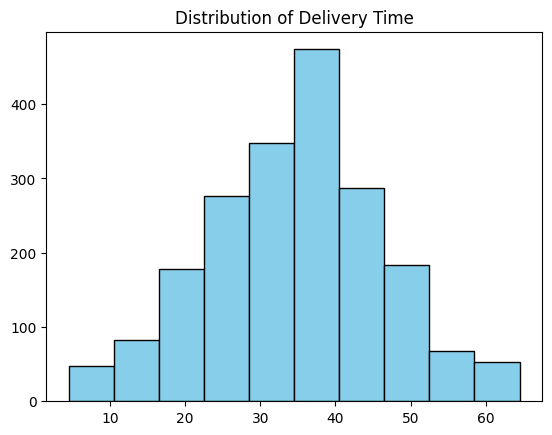

In [414]:
# Delivery time analysis

range_delivery = df['delivery_time_minutes'].max() - df['delivery_time_minutes'].min()
standard = df['delivery_time_minutes'].std()
print('Range:' , range_delivery)
print('Standard Deviation:' , standard)

plt.hist(df['delivery_time_minutes'] , bins=10 , color='skyblue' , edgecolor = 'black')
plt.title('Distribution of Delivery Time')
plt.show()

The distribution of delivery time is most frequent values between 35 and 42 minutes

Range: 40
Standard Deviation: 2.4253112825797625


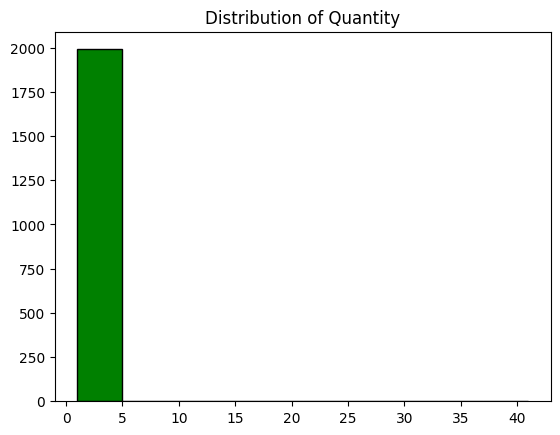

In [415]:
# Quantity analysis

range_quantity = df['quantity'].max() - df['quantity'].min()
standard = df['quantity'].std()
print('Range:' , range_quantity)
print('Standard Deviation:' , standard)

plt.hist(df['quantity'] , bins=10 , color='green' , edgecolor = 'black')
plt.title('Distribution of Quantity')
plt.show()



*   The chart says that most frequent values in quantity column is between 0 and 5
*   There are abnormal values in the data from 40 to 50, but they are less than 250 so they don't appear in the data set



Range: 249
Standard Deviation: 71.49142806759114


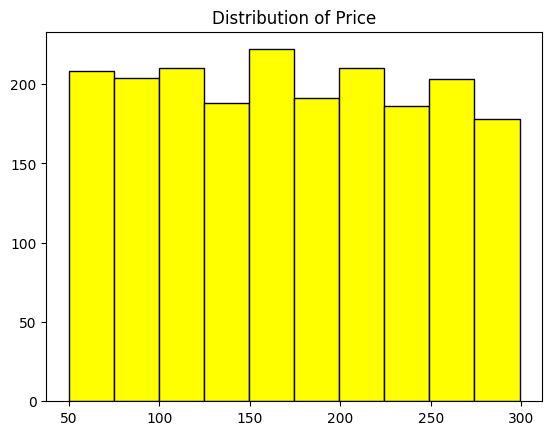

In [416]:
# Price analysis

range_price = df['price'].max() - df['price'].min()
standard = df['price'].std()
print('Range:' , range_price)
print('Standard Deviation:' , standard)

plt.hist(df['price'] , bins=10 , color='yellow' , edgecolor = 'black')
plt.title('Distribution of Price')
plt.show()

The chart shows that the price distribution is uniform and the prices are close to each other

Range: 29
Standard Deviation: 8.475697993571915


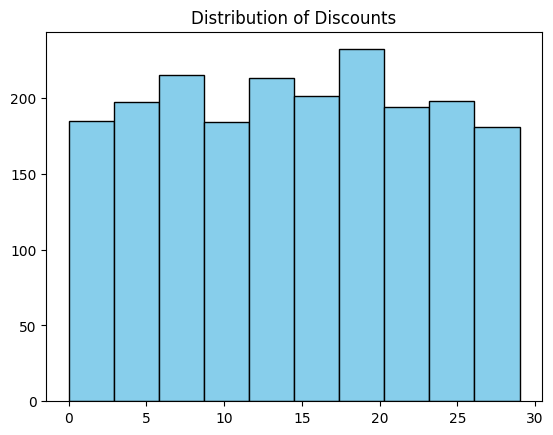

In [417]:
# Discount analysis

range_discount = df['discount'].max() - df['discount'].min()
standard = df['discount'].std()
print('Range:' , range_discount)
print('Standard Deviation:' , standard)

plt.hist(df['discount'] , bins=10 , color='skyblue' , edgecolor = 'black')
plt.title('Distribution of Discounts')
plt.show()

The chart shows that the Distribution of discounts is uniform and the discounts are close to each other

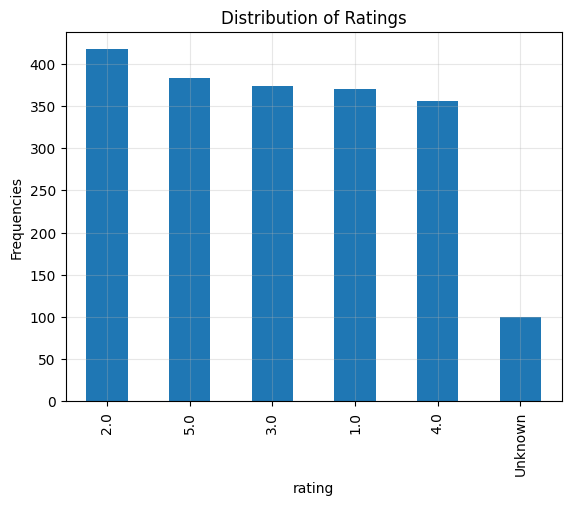

In [418]:
# Ratings analysis

count = df['rating'].value_counts()
count.plot(kind='bar')
plt.title('Distribution of Ratings')
plt.ylabel('Frequencies')
plt.grid(alpha=0.3)
plt.show()


*   The chart shows that most rating is 2, which indicates that the ratings are bad

*   But the other most value is 5, which s indicates that the raings are good



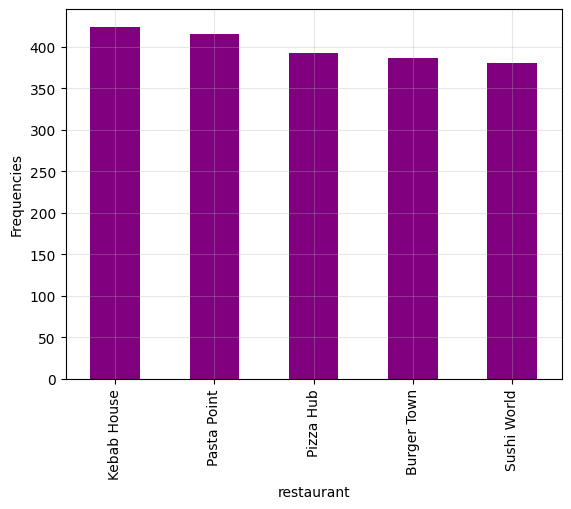

In [419]:
# Restaurant analysis

count_restaurant = df['restaurant'].value_counts()
count_restaurant.plot(kind='bar' , color='purple')
plt.ylabel('Frequencies')
plt.grid(alpha=0.3)



*   The chart shows that restaurants are close to each other in frequencies
*   The most restaurant in number of orders is Kebab House



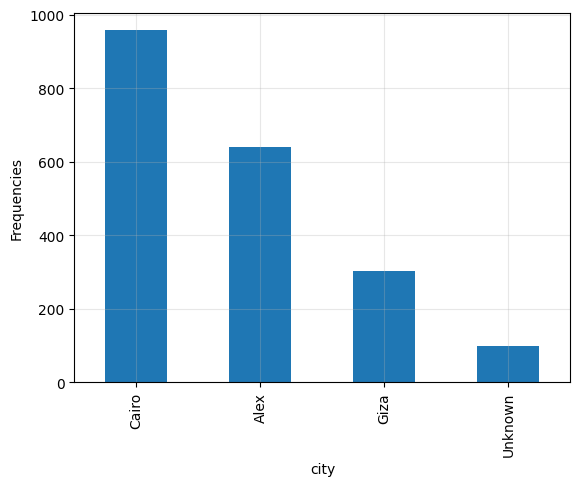

In [420]:
# City analysis

count_city = df['city'].value_counts()
count_city.plot(kind='bar')
plt.ylabel('Frequencies')
plt.grid(alpha=0.3)



*   The greatest city in the number of orders is cairo
*   There is Unknown column which indicates the missing values in the data set



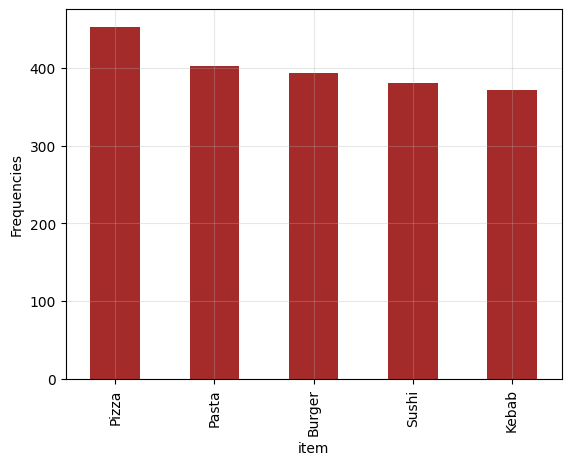

In [421]:
# Item analysis

count_item = df['item'].value_counts()
count_item.plot(kind='bar' , color='brown')
plt.ylabel('Frequencies')
plt.grid(alpha=0.3)


*   The chart shows that Best seller product is pizza
*   Other products are close to each other in the number of orders



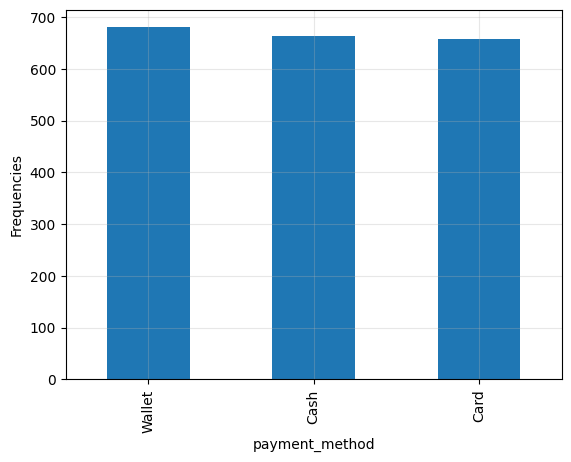

In [422]:
# Payment Method analysis

count_payment = df['payment_method'].value_counts()
count_payment.plot(kind='bar')
plt.ylabel('Frequencies')
plt.grid(alpha=0.3)



*   The values are close to each other, that means the customer uses 3 methods of payment
*   The most payment method used by customers is Wallet



In [423]:
# Step 3: Explore Relationships Between Variables

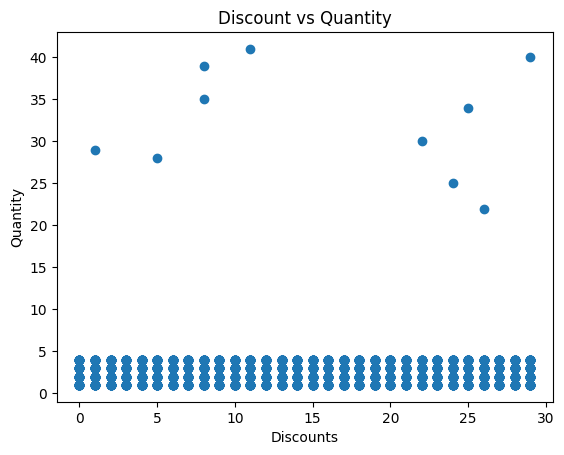

In [424]:
# Numerical vs Numerical

plt.scatter(df['discount'] , df['quantity'])
plt.xlabel('Discounts')
plt.ylabel('Quantity')
plt.title('Discount vs Quantity')
plt.show()



*   The chart shows that there is no relation ship between discounts and quantity as the customers don't buy more products as the discount increases
*   That because the large amount of quantity is on random placec on the chart



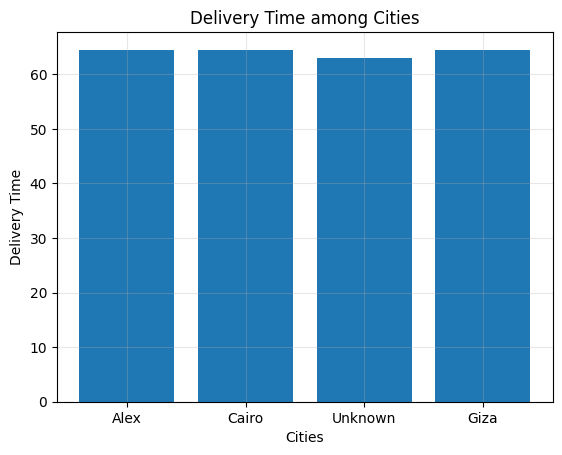

In [425]:
# Numerical vs Categorical

plt.bar(df['city'] , df['delivery_time_minutes'])
plt.xlabel('Cities')
plt.ylabel('Delivery Time')
plt.title('Delivery Time among Cities')
plt.grid(alpha=0.3)
plt.show()


*   The chart shows that all columns has the same height which indicate that all cities has the same delivery time

*   This happens because of capping which make the highest value in delivery time column equal 68.5



<Axes: xlabel='item'>

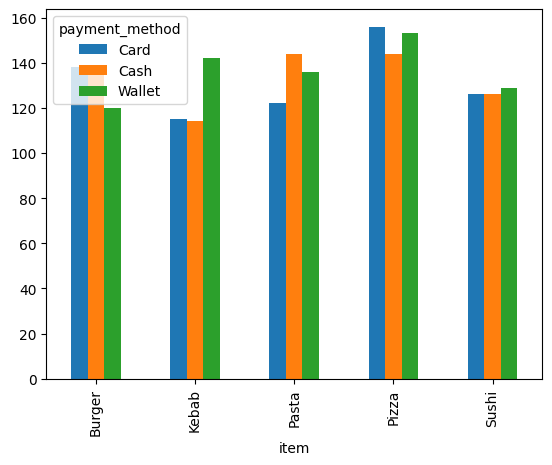

In [426]:
# Categorical vs Categorical

group = pd.crosstab(df['item'], df['payment_method'])
group.plot(kind='bar')






*   This chart answer the question of Does the type of food affect how customers pay?

1.   We will find in the chart that some type of food like Pizza which is the most expensive food and It's usually ordered at gatherings, people use card when pay after ordering it

   
2.   But the pasta which is less expensive than pizza and Usually ordered by individuals, people use cash when pay after ordering it















In [427]:
# Step 4: Review Data Subsets

In [428]:
# Customers groups

low_customer = df[(df['price'] <= 170) | (df['quantity'] <= 3)]
high_customer = df[(df['quantity'] > 3) | (df['price'] > 170)]

In [429]:
# Compare between two groups

 # Comparing ratings between two groups

clean_rating_high = pd.to_numeric(high_customer['rating'] , errors='coerce')
clean_rating_low = pd.to_numeric(low_customer['rating'] , errors='coerce')

compare_rating = {
     'Avreage of ratings between high value customers': clean_rating_high.mean(),
     'Avreage of ratings between low value customers': clean_rating_low.mean()
 }
compare_rating

{'Avreage of ratings between high value customers': np.float64(2.984113712374582),
 'Avreage of ratings between low value customers': np.float64(2.972205438066465)}


*   After comparing between customer gruops, we found that there is small diffrence between avreage ratings in two groups
*   This indicates the ratings doesn't change by changing the price and the quantity of the order



In [430]:
# comparing delivery time between groups

delivery_high = high_customer['delivery_time_minutes'].mean()
delivery_low = low_customer['delivery_time_minutes'].mean()

compare_delivery = {
    'Avreage of delivery time between high value customer' : delivery_high,
    'Avreage of delivery time between low value customer' : delivery_low
}
compare_delivery

{'Avreage of delivery time between high value customer': np.float64(34.655186064924784),
 'Avreage of delivery time between low value customer': np.float64(34.57696726019529)}



*   After comparing delivery time between customers, we found that there is small diffrence between avreage of delivery time between groups
*   That indicates that the delivery time doesn't change based on quantity or price of order



In [431]:
# Making new column called revenue

df['revenue'] = df['quantity'] * df['price']

In [432]:
# Restaurant categories

premium_resturant = df[(df['restaurant'] == 'Sushi World') | (df['restaurant'] == 'Kebab House')]
simple_resturant = df[(df['restaurant'] == 'Pizza Hub') | (df['restaurant'] == 'Pasta Point') | (df['restaurant'] == 'Burger Town')]

In [433]:
# Compare between two categories in avreage of revenue

print('Avreage revenue of Premium restaurant: ' , premium_resturant['revenue'].mean())
print('Avreage revenue of simple restaurant: ' , simple_resturant['revenue'].mean())

Avreage revenue of Premium restaurant:  479.5689440993789
Avreage revenue of simple restaurant:  440.92803347280335



*   We will find that the premium restaurants (kebab and sushi) have greater avreage of revenue per order which indicates that
customers' buy larger quantitis than other resturants' customers

*   And the simple restaurants (Burger, Pizza and Pasta) have less avreage of revenue than premium restaurant which indicates that the customers of simple restaurant tend to buy smaller quantities per order



<Axes: xlabel='restaurant'>

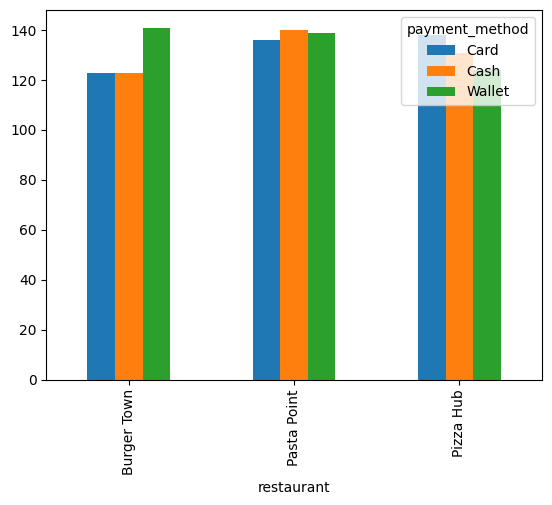

In [434]:
# Compare between two categories in payment methods

group_simple = pd.crosstab(simple_resturant['restaurant'], df['payment_method'])
group_simple.plot(kind='bar')

We will find that simple restaurants have a Variety in payment methods

*   The most used payment method in Burger town is wallet, This is probably because cash back offers which make customers use wallet instead of other payment methods

*   The most used payment method in Pasta point is cash, This is because pasta in most cases ordered by individuals so its quantity is less than other items so people prefer to pay with cash
*   The most used paymen method in Pizza hub is card, This is because Pizza is mostly ordered by groups in events so its quantity is more than other items so its price ibecome large so people prefer to pay using card


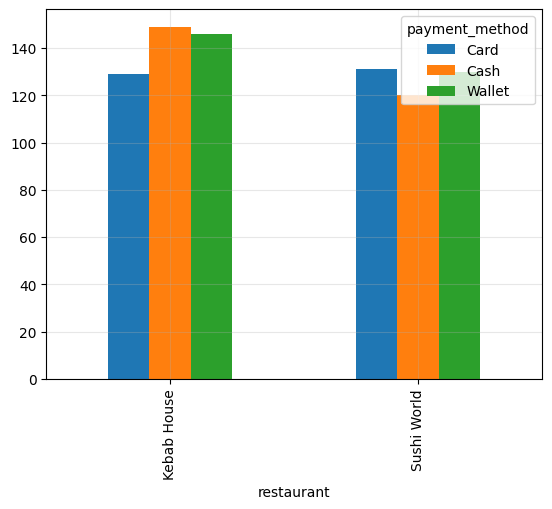

In [435]:
group_premium = pd.crosstab(premium_resturant['restaurant'], df['payment_method'])
group_premium.plot(kind='bar')
plt.grid(alpha=0.3)


We will find that Premium restaurants have a Variety in payment methods

*   The most used payment method in Kebab House is cash, This is probably because in Local restaurants customer prefer to pay with cash Even though the price is high
*   The most used payment method in Sushi world is wallet, This is because the cash back offers which make customers more comfortable when paying with the wallet



In [436]:
# Delivery performance groups

fast_delivery = df[df['delivery_time_minutes'] < 30]
slow_delivery = df[df['delivery_time_minutes'] >= 30]

In [437]:
# Comparing ratings between delivery time groups

clean_fast_delivery = pd.to_numeric(fast_delivery['rating'] , errors='coerce')
clean_slow_delivery = pd.to_numeric(slow_delivery['rating'] , errors='coerce')

print('Avreage ratings of fast delivery time:' , clean_fast_delivery.mean())
print('Avreage ratings of slow delivery time:' , clean_slow_delivery.mean())

Avreage ratings of fast delivery time: 2.993299832495812
Avreage ratings of slow delivery time: 2.9762087490406754




*   As we see the avreage of ratings is close to each other, that means that the customers don't change their ratings in the long delivery trips
*   We can explain this by the fact that long food delivery times happen due to obvious weather factors, so the customer is okay with that



In [438]:
# Step 5: Feature Engineering

In [439]:
# Feature Engineering

df['revenue'] = df['quantity'] * df['price']

By creating revenue column we can make many strong analysis like

*   Which restuarant has the most revenue
*   which item has the most revenue


And we can use it to answer the analysis objectives





In [440]:
# Step 6: Perform Data Visualization

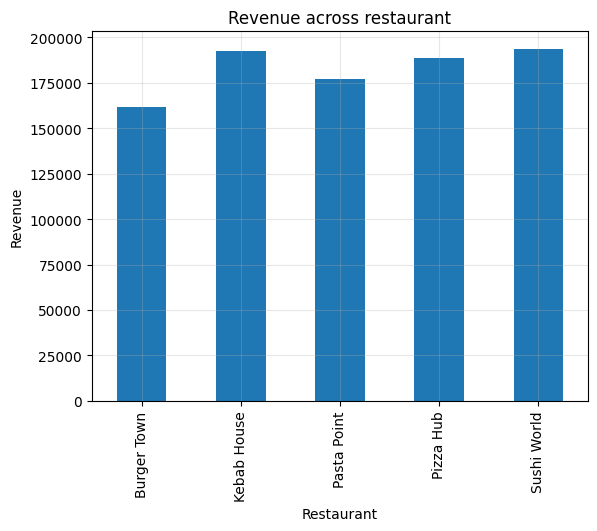

In [441]:
# Bar chart on revenue across restaurant

restaurant_revenue = df.groupby('restaurant')['revenue'].sum()
restaurant_revenue.plot(kind='bar')
plt.title('Revenue across restaurant')
plt.xlabel('Restaurant')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.show()



*   The Bar chart shows that the greatest restaurant in revenue is Sushi world
*   The least restaurant is Burger Town

*   This happened because of one of two things: either the number of his orders is few, or the order price is low.

*   The premium restaurants (sushi and kebab) are the most revenue restaurant









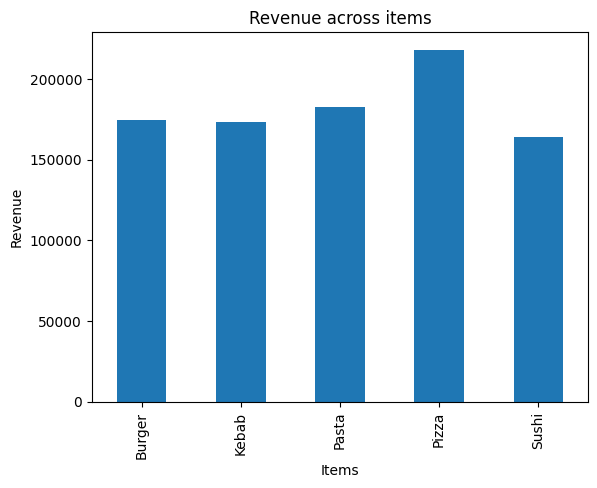

In [442]:
# Bar chart on revenue across items

restaurant_revenue = df.groupby('item')['revenue'].sum()
restaurant_revenue.plot(kind='bar')
plt.title('Revenue across items')
plt.xlabel('Items')
plt.ylabel('Revenue')
plt.show()



*   The most item in revenue is Pizza while the least is Sushi



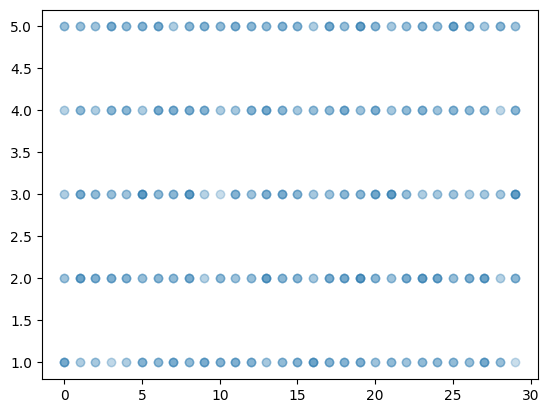

In [443]:
# Scatter plot

df['rating'] = pd.to_numeric(df['rating'] , errors='coerce')
plt.scatter(df['discount'] , df['rating'] , alpha=0.05)
plt.show()

The scatter plot shows that there is no relation ship between discounts and ratings as the customer doesn't increase the rating when the discounts increase

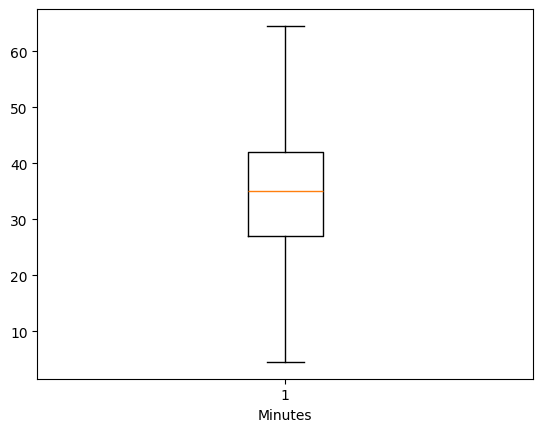

In [444]:
# Boxplot on delivery time

plt.boxplot(df['delivery_time_minutes'])
plt.xlabel('Minutes')
plt.show()

The box plot shows that there is no outliers becuase we capped them to upper and lower limits

Text(0.5, 1.0, 'Revenue over days')

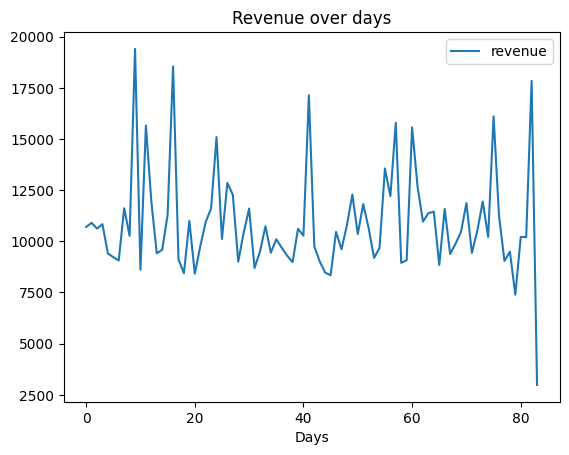

In [445]:
# line chart on revenue over days

df['order_day'] = df['order_date'].dt.date
daily_revenue = df.groupby('order_day')['revenue'].sum().reset_index()
daily_revenue.plot(kind='line')
plt.xlabel('Days')
plt.title('Revenue over days')


*   The line chart is in Zigzag shape, and that's normal because Revenue change over days.
*   The least day in revenue is 2024-03-24, because in this day there is only 8 orders



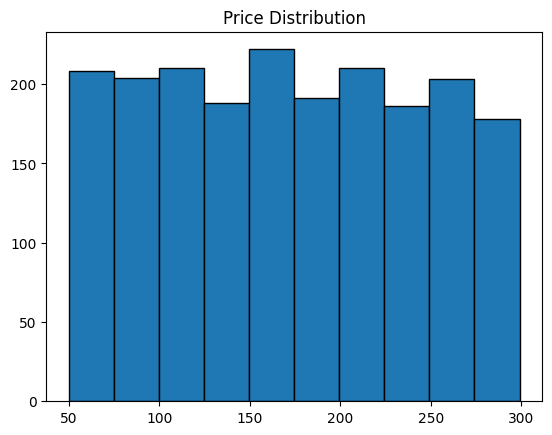

In [446]:
# Histogram on price distribution

plt.hist(df['price'] , bins=10 , edgecolor='black')
plt.title('Price Distribution')
plt.show()



*   The histogram shows the distribution of Price
*   All prices are close to each other



Text(0.5, 1.0, 'Payment methods usage')

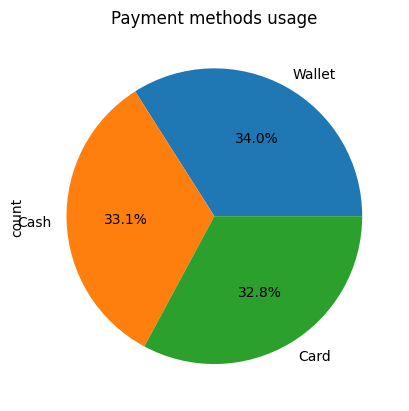

In [447]:
# Count plot on payment methods

count = df['payment_method'].value_counts()
count.plot(kind = 'pie' , autopct = '%1.1f%%')
plt.title('Payment methods usage')



 The pie chart shows that
*   The three payment methods are close to each other in customer usage



*   the most used payment method is Wallet and the least is Card
   



In [448]:
# Step 1: Interpret Results & Generate Insights



**Key Finding:** There is no correlation between discount and quantity

**Supporting Evidence:** The correlation between discounts and quantity is 0.0100 and the scatter plot

**Insight(Business Impact):** The customer buys only as much as they need, no matter how big the discounts are, so discount doesn't really matter in increasing the quantity

In [449]:

correlation = df['discount'].corr(df['quantity'])
print(f"Correlation: {correlation:.4f}")

Correlation: 0.0100


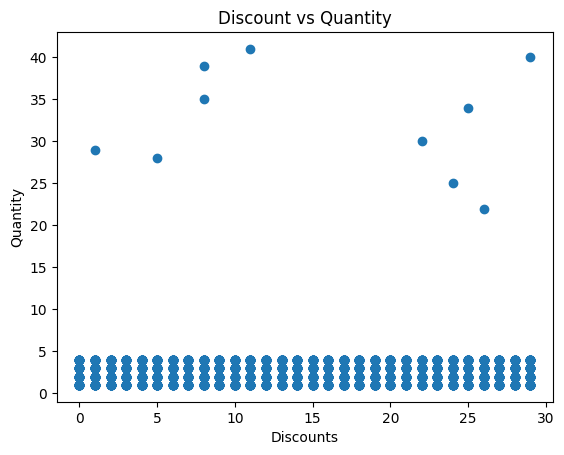

In [450]:
plt.scatter(df['discount'] , df['quantity'])
plt.xlabel('Discounts')
plt.ylabel('Quantity')
plt.title('Discount vs Quantity')
plt.show()



**Key Finding:** The most used payment method is Wallet

**Supporting Evidence:** The pie chart

**Insight(Business Impact):** The customers is using Wallet because of cash back offers and it is easy to use, so We can improve payment methods through the wallet since it's the most used method

Text(0.5, 1.0, 'Payment methods usage')

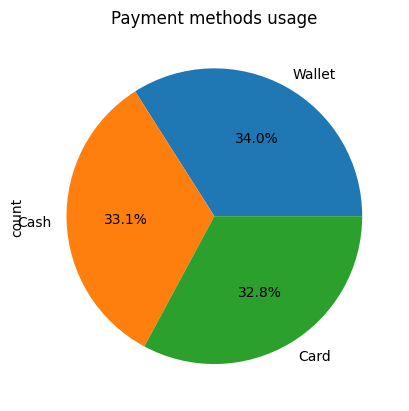

In [451]:
count = df['payment_method'].value_counts()
count.plot(kind = 'pie' , autopct = '%1.1f%%')
plt.title('Payment methods usage')



**Key Finding:** The Best-selling dish is Pizza and the most revenue product is pizza

**Supporting Evidence:** The Bar chart

**Insight(Business Impact):** Since pizza is the best-selling and most profitable, it is the main pillar of the business, so it should be taken care of through various offers.

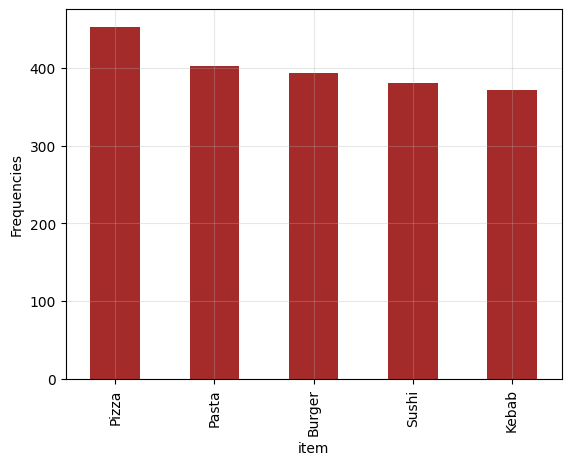

In [452]:
count_item = df['item'].value_counts()
count_item.plot(kind='bar' , color='brown')
plt.ylabel('Frequencies')
plt.grid(alpha=0.3)

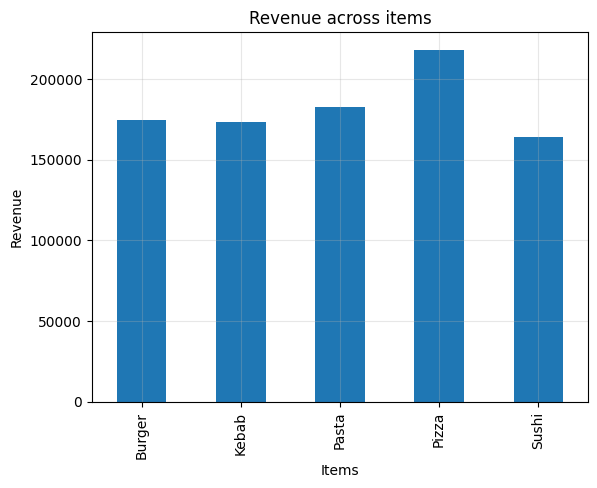

In [453]:
restaurant_revenue = df.groupby('item')['revenue'].sum()
restaurant_revenue.plot(kind='bar')
plt.title('Revenue across items')
plt.xlabel('Items')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.show()

# ##Analysis Objectives

   Which restaurant is the best in profits?

   Which item is the best in profits?

   What are the avreage delivery times for orders?


  Understand customer behavior



  1.   What's the most common payment method used by customers?

  1.   What's the dish that customers order the most?
  2.   Which restaurant does the customer order from the most?






In [454]:
# Step 2: Answer Analysis Objectives

Analysis objectives: Which restaurant is the best in profits?

Findings: I found that Sushi world and kebab house are the best restaurant in revenue, Burger town is the least in revenue

Final answer: The best restaurant in profits is Sushi world


---



Analysis objectives: Which item is the best in profits?

Findings: I found that Pizza is the best item in profits, while the least is Sushi

Final answer: The best Item in profits is Pizza


---




Analysis objectives: What are the avreage delivery times for orders?

Findings: I found that after treating all problems in delivery time column ( missing values , outliers ), The average of delivery time is 34.5 minutes

Final answer: The avreage delivery time for orders is 34.5 minutes



---




# Understanding Customer behavior

Analysis objectives: What's the most common payment method used by customers?


Findings: I found that The three payment method are close to each other in usage, but the most used payment method is Wallet

Final answer: The most common payment method is Wallet



---




Analysis objectives: What's the dish that customers order the most?


Findings: I found that The most ordered dish by customers is Pizza and the least is Kebab

Final answer: The dish that customers order the most is Pizza


---




Analysis objectives: Which restaurant does the customer order from the most?



Findings: I found that the restaurant are close to each other but the most restaurant in number of orders is Kebab house and the least is Sushi world

Final answer: The restaurant that customers order from the most is Kebab house



---




In [455]:
# Step 3: Develop Recommendations

**Recommendation**: Since pizza is the best-selling and most profitable product, we could set aside a budget for pizza ads and run promotions like 'buy a pizza and get a drink at a lower price' to boost drink sales with pizza, and make sure there are enough ingredients in the storage.


**Supporting Evidence**: The bar chart

**Expected Business Impact**: This act will boost drink sales and ensure that pizza are avilable in all branches


---



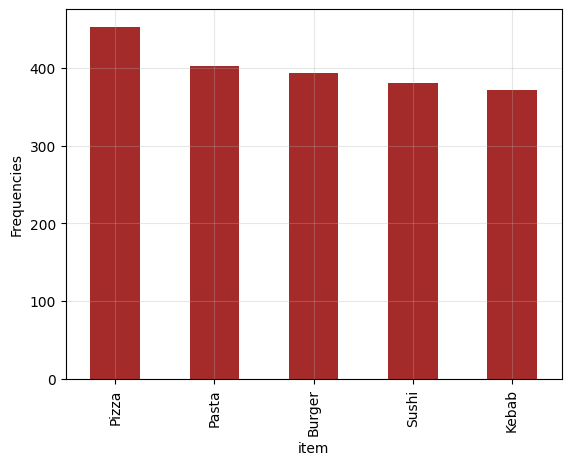

In [456]:
count_item = df['item'].value_counts()
count_item.plot(kind='bar' , color='brown')
plt.ylabel('Frequencies')
plt.grid(alpha=0.3)

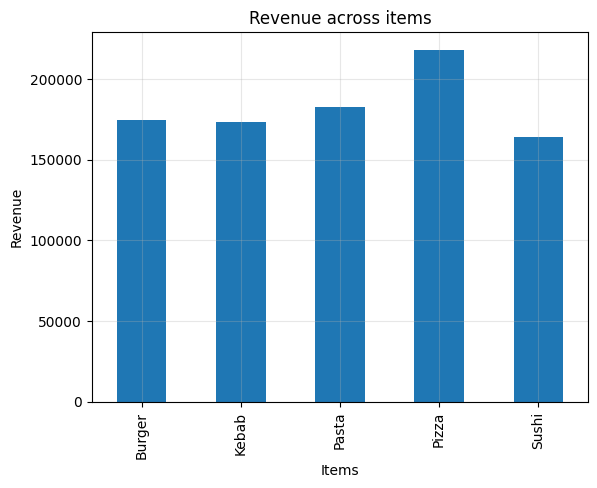

In [457]:
restaurant_revenue = df.groupby('item')['revenue'].sum()
restaurant_revenue.plot(kind='bar')
plt.title('Revenue across items')
plt.xlabel('Items')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.show()



---


**Recommendation**: Marketing focus on the wallet as a primary payment method


**Supporting Evidence**: The pie chart

**Expected Business Impact**: It will lead to improved digital tracking of transactions



---



Text(0.5, 1.0, 'Payment methods usage')

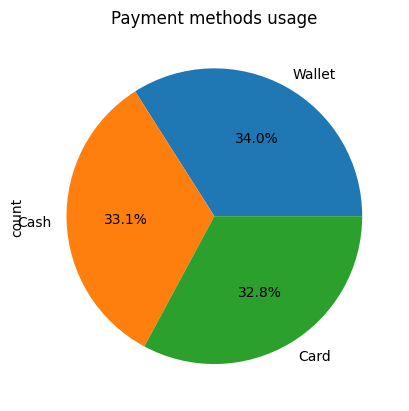

In [458]:
count = df['payment_method'].value_counts()
count.plot(kind = 'pie' , autopct = '%1.1f%%')
plt.title('Payment methods usage')



---


**Recommendation**: Since Burger Town is the least profitable restaurant even though the number of orders is close to the other restaurants, we need to do a big promotional campaign and reprice the products.


**Supporting Evidence**: The Bar chart

**Expected Business Impact**: If the promotional campaign succeeds, the restaurant will be one of the most successful and profitable ones.



---



In [459]:
# Showing that number of orders are close to other restaurant
df['restaurant'].value_counts()

,count
restaurant,
Kebab House,424
Pasta Point,415
Pizza Hub,393
Burger Town,387
Sushi World,381


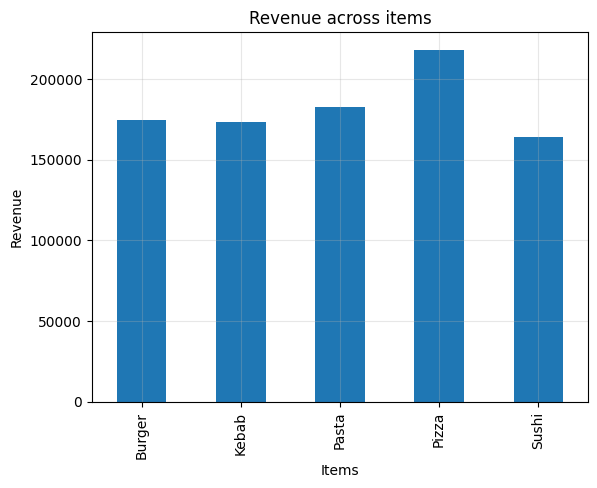

In [460]:
restaurant_revenue = df.groupby('item')['revenue'].sum()
restaurant_revenue.plot(kind='bar')
plt.title('Revenue across items')
plt.xlabel('Items')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.show()



---


**Recommendation**: Since discounts don't increase the quantity that customer buys or the ratings, we suggest reducing discounts and improving food and service quality to increase ratings.


**Supporting Evidence**: The scatter plot that shows there is no correlation between discounts and quantity or discounts and ratings

**Expected Business Impact**: The ratings will increase so it will make customers more comfortable with the food and service quality



---



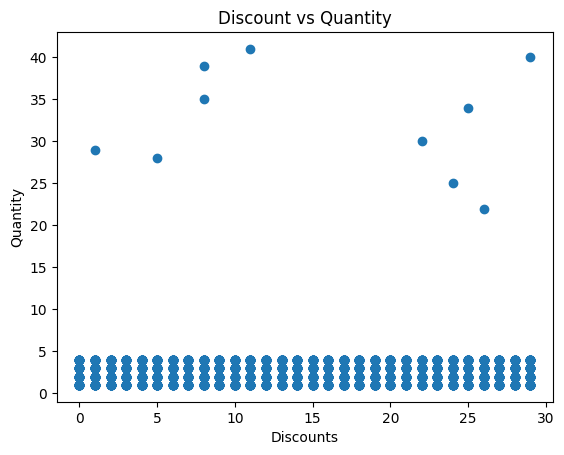

In [461]:
# There is no correlation between discount and quantity
plt.scatter(df['discount'] , df['quantity'])
plt.xlabel('Discounts')
plt.ylabel('Quantity')
plt.title('Discount vs Quantity')
plt.show()

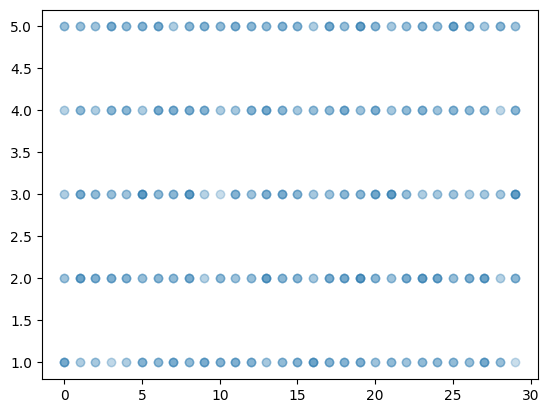

In [462]:
# There is no correlation between discount and ratings
df['rating'] = pd.to_numeric(df['rating'] , errors='coerce')
plt.scatter(df['discount'] , df['rating'] , alpha=0.05)
plt.show()

In [463]:
# Step 4: Final Conclusion

## Step 4: Final Conclusion

This project aims to understand restaurant performance and customer behavior on a food delivery platform by cleaning data, creating new features, doing visual analysis, and making recommendations.

### Main Findings
- **Sushi world** is the most profitable but the **Burger Town** is the least with a difference of about 36,000.

- **Kebab House** Kebab Restaurant is the top restaurant in ratings and number of orders
- **Pizza** Pizza is the best-selling product and the most profitable product.
- **Wallet** is the most used payment method between customers
- Delivery time has no relation with ratings
- Discounts doesn't affect on ratings
- Avreage Delivery time for order is 34.5

### Key Insights
- The strong performance gap between restaurants (Sushi World vs Burger Town) is driven by **average order value, not the quantity of orders**,  both restaurants receive a similar number of orders.

- **Pizza** high revenue comes mainly from its **higher unit price**, because the number of orders of it close to other products.

- There's no relation between discounts and ratings, it's because customer's rating is influenced by other things like the quality of the food.

- As the same reason there is no relation between delivery time and ratings.

### Major Recommendations
1. we could set aside a budget for pizza ads and run promotions like 'buy a pizza and get a drink at a lower price' to boost drink sales with pizza, and make sure there are enough ingredients in the storage.


2. Review of the pricing strategy in Burger Town to treat the gap between it and other restaurants

3. Instead of increasing discounts, we could improve food quality to improve customers ratings as discounts doesn't affect on it

4. Paying attention to the wallet since it's the most used payment method

### Overall Project Outcomes
- Overall, the platform is performing well, with balanced performance across restaurants and payment methods.
- Pizza stands out as the strongest product, while Burger Town needs attention to close the revenue gap with other restaurants.
- Discounts and delivery speed had no effect on ratings, so future improvements should focus more on service quality than pricing.